<a href="https://colab.research.google.com/github/cyeef/Data-Science-Portfolio-C21-/blob/main/Exercises/3b-EDA.Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Exercise

In this exercise, you will read in your data, do some preliminary data cleaning, and do EDA to better understand your data.

[The dataset]( http://ddc-datascience.s3.amazonaws.com/auto-mpg.csv ) for this exercise is saved in an Amazon Web Services ( AWS ) S3 bucket. The original source and details about this dataset can be found [here](https://archive.ics.uci.edu/ml/datasets/Auto+MPG).

Below are the steps you'll need to perform for the EDA. Make sure to use text blocks to organize your analysis.  Discuss any trends/relationships/issues you discover at each step in the analysis.

1. Import `pandas` as `pd`, `matplotlib.pyplot as plt`, and `seaborn as sns`.
1. Read in the csv file found at http://ddc-datascience.s3.amazonaws.com/auto-mpg.csv .
1. Understand your data by using at least 4 pandas methods (e.g., `.head()`).
1. Make a copy of your data frame. In your copy, remove any rows that contain null values.  
1. Calculate summary statistics on one or more columns.
1. Generate at least 3 univariate plots.
1. Generate a correlation plot.
1. Generate a pairplot.
9. If we were going to build a predictive model ( supervised learning ) using this dataset, what do you think would be a good response ( aka target ) variable and why?

## Step 1: Import



Import pandas as pd, matplotlib.pyplot as plt, and seaborn as sns.

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Get data


Read in the csv file found at http://ddc-datascience.s3.amazonaws.com/auto-mpg.csv.


In [121]:
df = pd.read_csv("http://ddc-datascience.s3.amazonaws.com/auto-mpg.csv")

## Step 3: Understand data


Understand your data by using at least 4 pandas methods (e.g., .head()).


In [122]:
df.head()             # prints first five and can take a int so I can df.head(8)  prints first 8 rows with columns


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [123]:
df.tail()             # prints last five and can take a int so I can df.eight(8)  prints last 8 rows with columns


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
393,27.0,4,140.0,86.0,2790,15.6,82,1
394,44.0,4,97.0,52.0,2130,24.6,82,2
395,32.0,4,135.0,84.0,2295,11.6,82,1
396,28.0,4,120.0,79.0,2625,18.6,82,1
397,31.0,4,119.0,82.0,2720,19.4,82,1


In [124]:
df.shape              # shows the total rows and total columns (r,c)


(398, 8)

In [125]:
df.info()               # gives me the column names, data types (str, floats, int), and null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


In [126]:
df.describe()           # statistics summary values mean, standard deviation, count, min, max, distribution


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [127]:
df.isnull().sum()          # null count per column - six in horespower

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0


In [128]:
df.isnull().sum().sum()            # total nulls in entire df

np.int64(6)

In [129]:
df.duplicated().sum()              # duplicate rows

np.int64(0)

In [130]:
df.columns.tolist()                # list of column names

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year',
 'origin']

In [131]:
df.dtypes                          # data type of each column

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model year,int64
origin,int64


In [146]:
df['origin'].value_counts()

,count
origin,
1,245
3,79
2,68


## Step 4: Copy and clean


Make a copy of your data frame. In your copy, remove any rows that contain null values.


In [132]:
# this creates a copy
df = df.copy()


print(df.copy)


<bound method NDFrame.copy of       mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model year  origin  
0            70       1  
1            70       1  
2            70       1  
3

In [133]:
df = df.dropna()
print(df.dropna)
df.shape

<bound method DataFrame.dropna of       mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model year  origin  
0            70       1  
1            70       1  
2            70       1

(392, 8)

In [134]:
# trying df,dropna().copy()  Samee as a bove (392, 8)  when it was (398, 8) lost 6 rows due to null
df_dropped = df.dropna().copy()
print(f"Drop nulls: {df_dropped.shape}")

Drop nulls: (392, 8)


In [135]:
# filll empty cells with mean values for horsepower
df_mean = df.copy()
df_mean['horsepower'] = df_mean['horsepower'].fillna(df_mean['horsepower'].mean())
print(f"Mean:   {df_mean.shape}")

Mean:   (392, 8)


In [136]:
# filling with median
df_median = df.copy()
df_median['horsepower'] = df_median['horsepower'].fillna(df_median['horsepower'].median())
print(f"Median: {df_median.shape}")

Median: (392, 8)


## Step 5: Summary stats


Calculate summary statistics on one or more columns.


In [137]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [138]:
df['mpg'].describe() # summary statistics on the MPG column

,mpg
count,392.000000
mean,23.445918
std,7.805007
min,9.000000
25%,17.000000
50%,22.750000
75%,29.000000
max,46.600000


In [139]:
df['weight'].describe()  # summary statistics on the Weight column

,weight
count,392.000000
mean,2977.584184
std,849.402560
min,1613.000000
25%,2225.250000
50%,2803.500000
75%,3614.750000
max,5140.000000


In [140]:
df['acceleration'].describe()   # summary statistics on the Weight column

,acceleration
count,392.000000
mean,15.541327
std,2.758864
min,8.000000
25%,13.775000
50%,15.500000
75%,17.025000
max,24.800000


## Step 6: Univariate plots


Generate at least 3 univariate plots.

MPG Box plot shows fuel efficency in vehicles median fuel consumption at about 23 miles a gallon.
accerlation histogram majority of cars acceraltion to 60 is between 13 and 18 seconds.
Model year more cars sold in between 70-74 with a drop and an additonal peak in the 80s


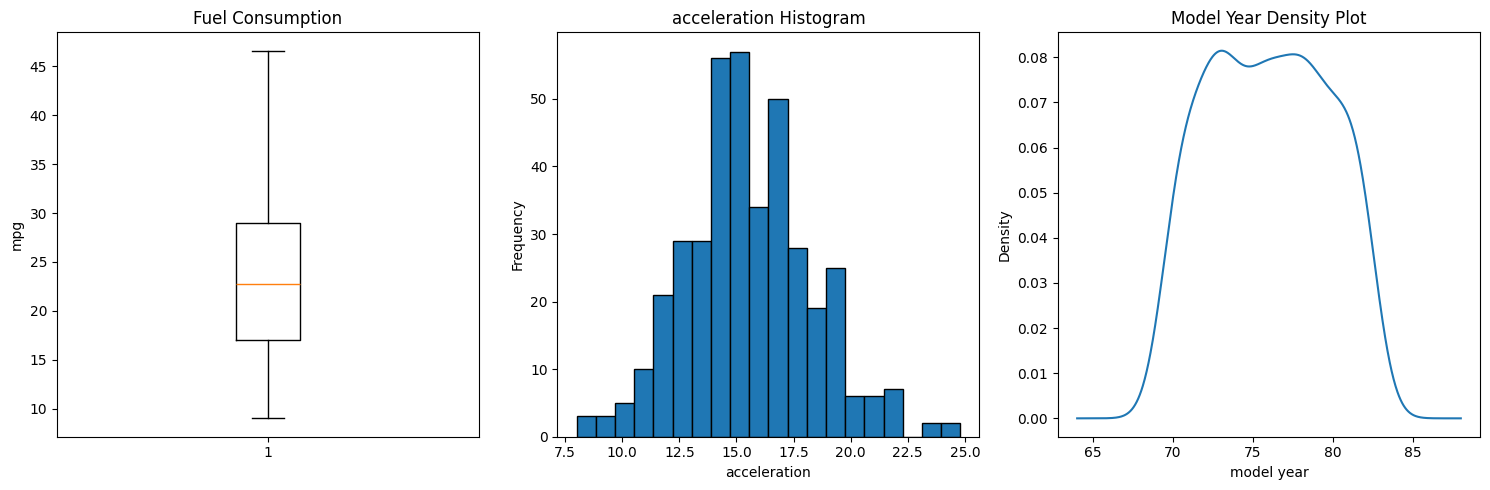

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box Plot
axes[0].boxplot(df['mpg'].dropna())
axes[0].set_title('Fuel Consumption')
axes[0].set_ylabel('mpg')

# Histogram
axes[1].hist(df['acceleration'].dropna(), bins=20, edgecolor='black')
axes[1].set_title('acceleration Histogram')
axes[1].set_xlabel('acceleration')
axes[1].set_ylabel('Frequency')

# Density Plot
df['model year'].dropna().plot.kde(ax=axes[2])
axes[2].set_title('Model Year Density Plot')
axes[2].set_xlabel('model year')

plt.tight_layout()
plt.show()

## Step 7: Bivariate plot (1/2)


Generate a correlation plot.

Weight and mpg negatively correlated - horsepower and displacement positively correlated - model year and orgin moderatly correlated


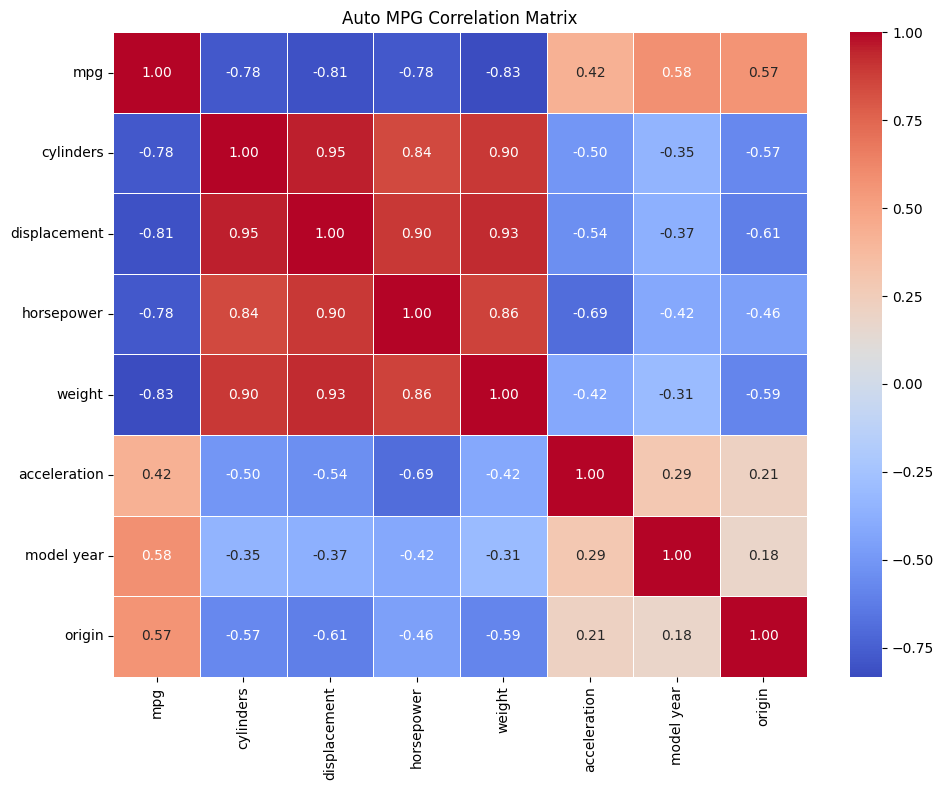

In [144]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('Auto MPG Correlation Matrix')
plt.tight_layout()
plt.show()

## Step 8: Bivariate plot (2/2)


Generate a pairplot.


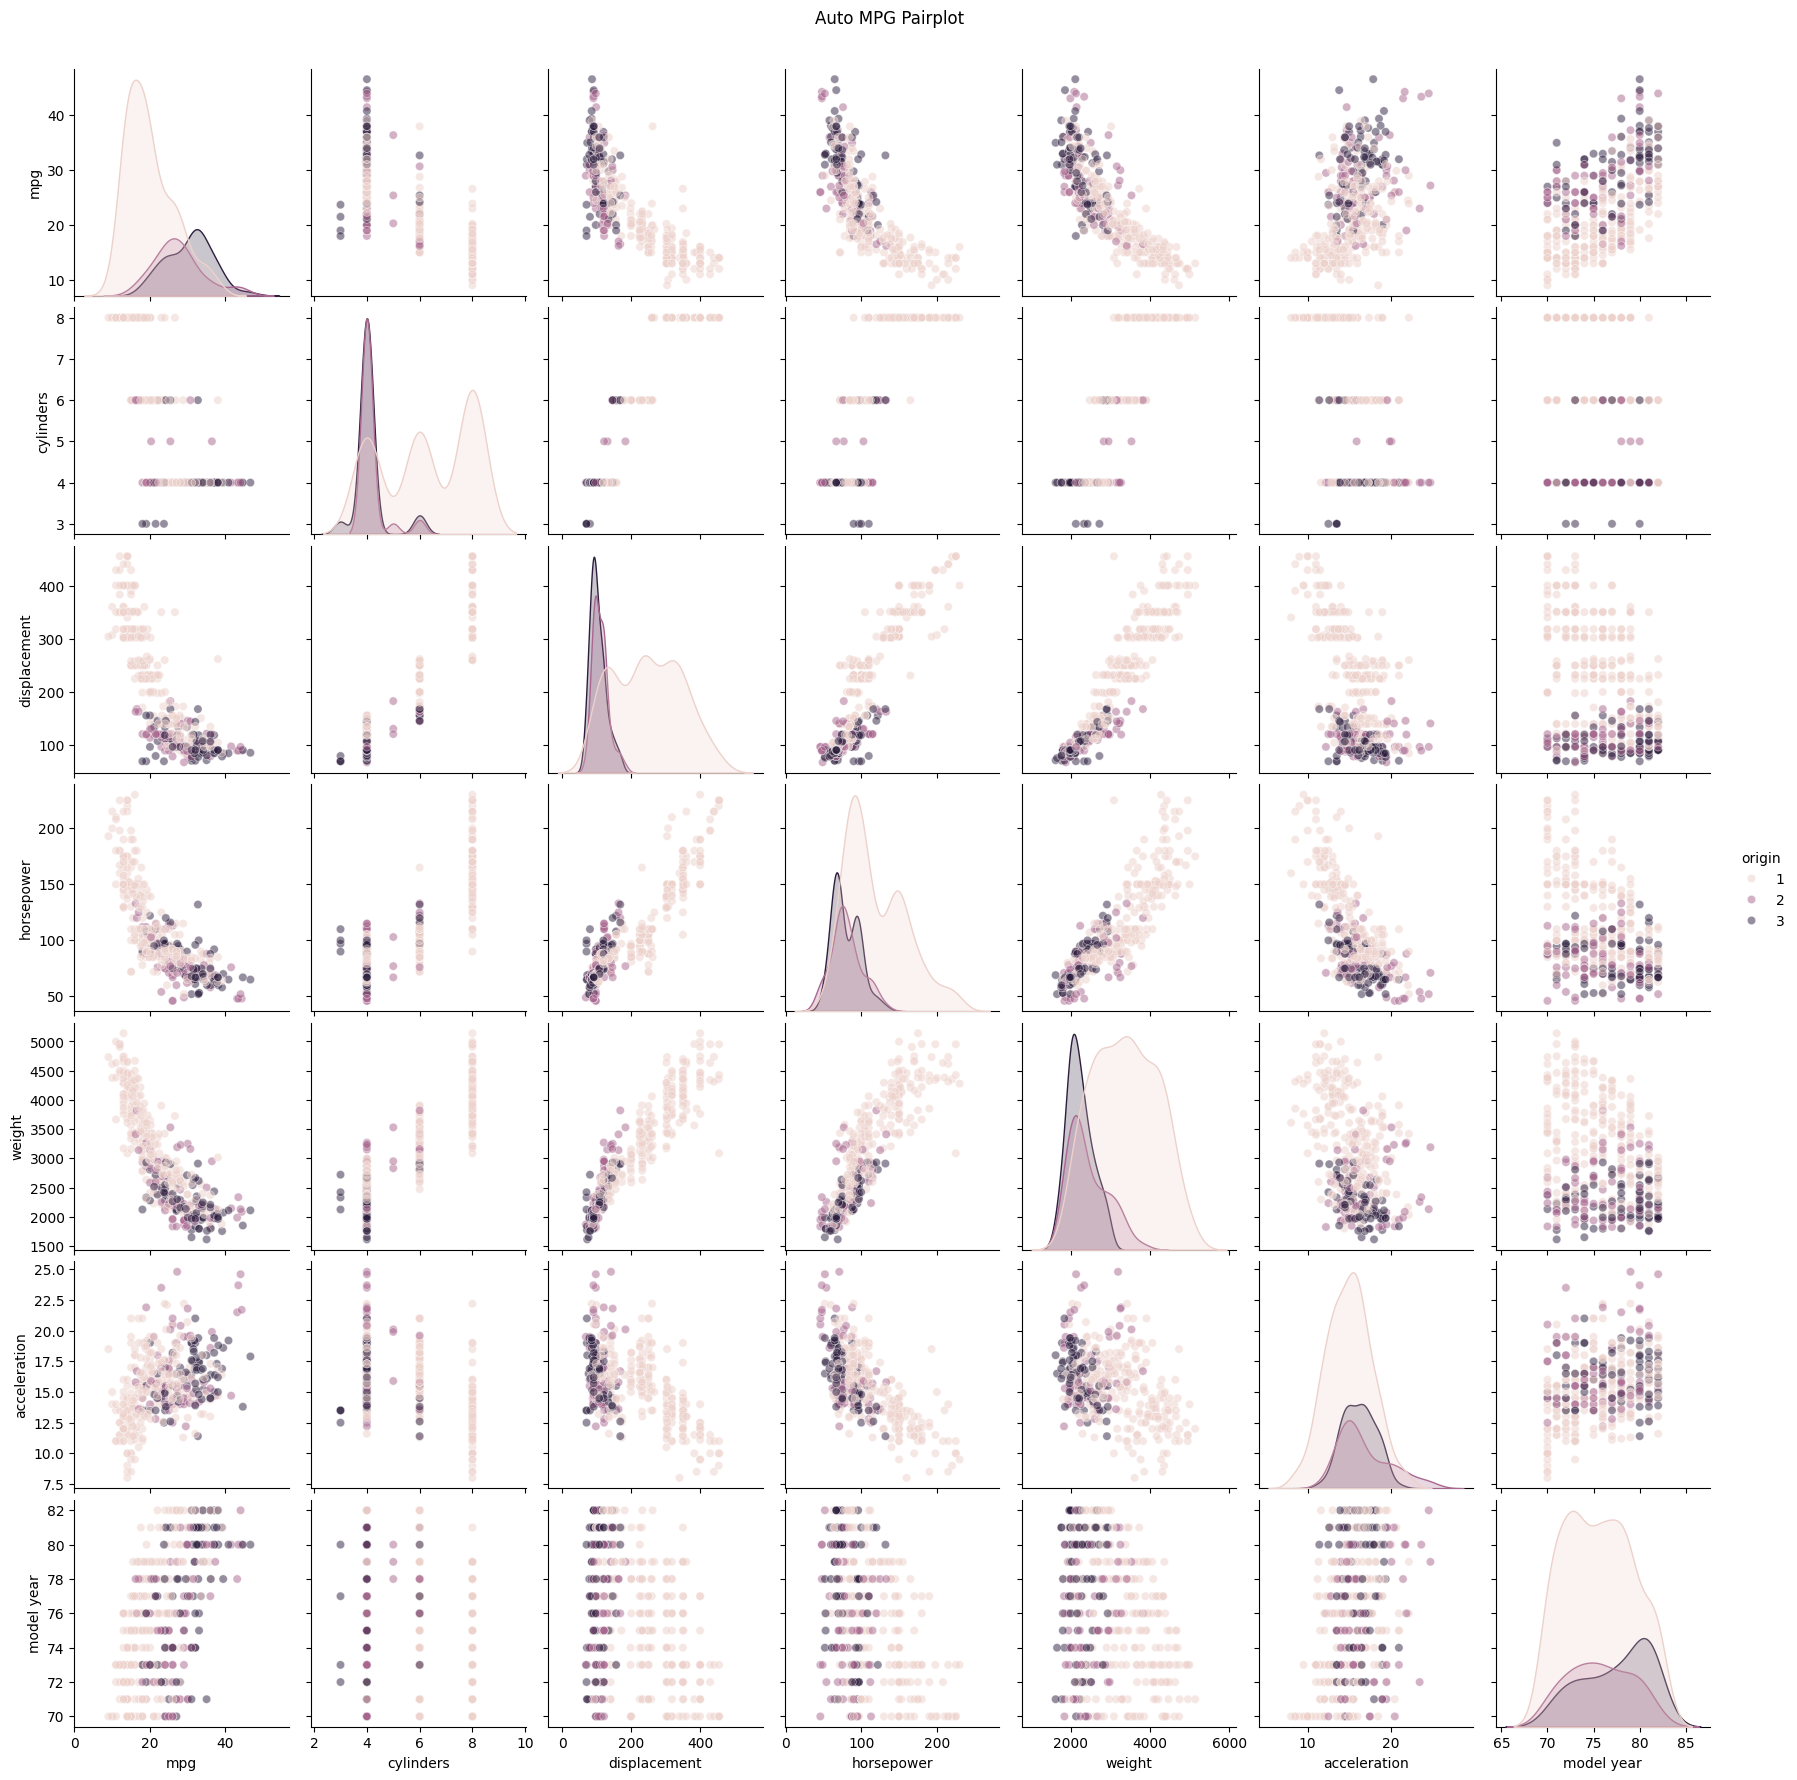

In [148]:
sns.pairplot(df,
             hue='origin',
             plot_kws={'alpha': 0.5})
plt.suptitle('Auto MPG Pairplot', y=1.02)
plt.show()

## Step 9: Conclusion


If we were going to build a predictive model ( supervised learning ) using this dataset, what do you think would be a good response ( aka target ) variable and why?

Our target value should be the continous numerical values of MPG.  MPG and the other features in the data set have positive and negative relationships.  Which can be good predictors in our model - a simple question like can we improve mpg if we reduce weight or can we increase horsepower and reduce fuel cost?  https://archive.ics.uci.edu/dataset/9/auto+mpg  classifies this data set as a regression model, so our supervised ML model would be regression.

